# MPDOK · Neural Architecture Search — MNIST MLP Sweep

**Premise:** Because MPDOK's v9 Fortran/cuBLAS engine can train an MNIST MLP in <100 ms,
we can afford to *brute-force* the architecture space that normally costs researchers days.

| Sweep | Configs | ~Time |
|-------|---------|-------|
| 4 depths × 8 widths (§2) | 32 | ~75 s |
| 5 depths × 8 widths + 3 LRs (§2b) | 120 | ~4 min |
| Top-3 re-trained at 30 epochs (§4) | 3 | ~2 min |

**Narrative:**
1. **§2** — sweep (depth × width) grid, record val accuracy & training time
2. **§3** — heatmap: depth × width → colour = accuracy, annotation = time
3. **§4** — top-3 head-to-head at 30 epochs
4. **§5** — Hessian eigenspectrum: *why* the winner wins (flatter loss landscape)

## §0 — Setup

In [51]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
import sys, importlib
sys.path.insert(0, '/var/home/fraser/machine_learning/fortran/examples/collected_examples/matrix_dot/tensor13/tensor_core_engine_v5')

import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import Normalize
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__}  device={device}')
if device == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

PyTorch 2.9.0+cu130  device=cuda
  GPU: NVIDIA GeForce RTX 4060


## §1 — Define the Sweep

Hidden layers are **uniform width**: `depth=3, width=256 → [256, 256, 256]`.
This gives clean 2-D axes for the heatmap.

We use `sweep.grid_sweep()` which pre-loads MNIST once and reuses it across all runs.

In [53]:
from MPDOK.nas_sweep.sweep import grid_sweep, lr_sweep, top_n_extended

# Primary grid
DEPTHS = [2, 3, 4, 5]
WIDTHS = [16, 32, 64, 128, 256, 512, 768, 1024]
EPOCHS = 10

print(f"Grid: {len(DEPTHS)} depths × {len(WIDTHS)} widths = "
      f"{len(DEPTHS)*len(WIDTHS)} configs  @ {EPOCHS} epochs each")
print("Uniform hidden layers: depth=d, width=w → [w]*d")

Grid: 4 depths × 8 widths = 32 configs  @ 10 epochs each
Uniform hidden layers: depth=d, width=w → [w]*d


## §2 — Run the Grid Sweep

Results are printed live as each config finishes.

In [54]:
import time
t0 = time.perf_counter()
results = grid_sweep(depths=DEPTHS, widths=WIDTHS, epochs=EPOCHS,
                     device=device, verbose=True)
print(f"\nTotal sweep time: {time.perf_counter()-t0:.1f}s")

  [  1/32]  depth=2  width=  16  hidden=(16, 16)
          val_acc=0.9302  time=2.0s  params=13,002
  [  2/32]  depth=2  width=  32  hidden=(32, 32)
          val_acc=0.9556  time=1.8s  params=26,506
  [  3/32]  depth=2  width=  64  hidden=(64, 64)
          val_acc=0.9626  time=1.7s  params=55,050
  [  4/32]  depth=2  width= 128  hidden=(128, 128)
          val_acc=0.9714  time=1.8s  params=118,282
  [  5/32]  depth=2  width= 256  hidden=(256, 256)
          val_acc=0.9763  time=1.9s  params=269,322
  [  6/32]  depth=2  width= 512  hidden=(512, 512)
          val_acc=0.9816  time=1.8s  params=669,706
  [  7/32]  depth=2  width= 768  hidden=(768, 768)
          val_acc=0.9824  time=1.9s  params=1,201,162
  [  8/32]  depth=2  width=1024  hidden=(1024, 1024)
          val_acc=0.9849  time=2.2s  params=1,863,690
  [  9/32]  depth=3  width=  16  hidden=(16, 16, 16)
          val_acc=0.9324  time=2.0s  params=13,274
  [ 10/32]  depth=3  width=  32  hidden=(32, 32, 32)
          val_acc=0.95

In [55]:
# Summarise as a table
import pandas as pd

rows = [{"depth": r.depth, "width": r.width, "hidden": str(r.hidden),
         "val_acc": r.val_acc, "final_acc": r.final_acc,
         "time_s": r.train_time, "params": r.num_params}
        for r in results]
df = pd.DataFrame(rows).sort_values("val_acc", ascending=False)
df["val_acc_%"] = (df["val_acc"] * 100).round(2)
df["time_s"]    = df["time_s"].round(1)
df["params"]    = df["params"].apply(lambda x: f"{x:,}")
print(df[["depth","width","val_acc_%","time_s","params"]].to_string(index=False))

 depth  width  val_acc_%  time_s    params
     2   1024      98.49     2.2 1,863,690
     3   1024      98.37     3.0 2,913,290
     4    768      98.36     2.9 2,382,346
     4   1024      98.32     3.9 3,962,890
     5   1024      98.32     5.2 5,012,490
     3    768      98.28     2.4 1,791,754
     3    512      98.27     2.1   932,362
     2    768      98.24     1.9 1,201,162
     5    768      98.19     3.7 2,972,938
     2    512      98.16     1.8   669,706
     5    512      98.11     3.2 1,457,674
     4    512      98.07     2.4 1,195,018
     4    256      98.04     2.4   400,906
     3    256      97.83     2.1   335,114
     5    256      97.80     2.7   466,698
     2    256      97.63     1.9   269,322
     4    128      97.48     2.4   151,306
     3    128      97.43     2.1   134,794
     5    128      97.42     2.7   167,818
     2    128      97.14     1.8   118,282
     4     64      96.51     2.4    63,370
     3     64      96.32     2.1    59,210
     2     

## §3 — Heatmap: Depth × Width → Val Accuracy

Each cell is coloured by validation accuracy.
Top-right annotation is training time (s).
The star marks the best configuration.

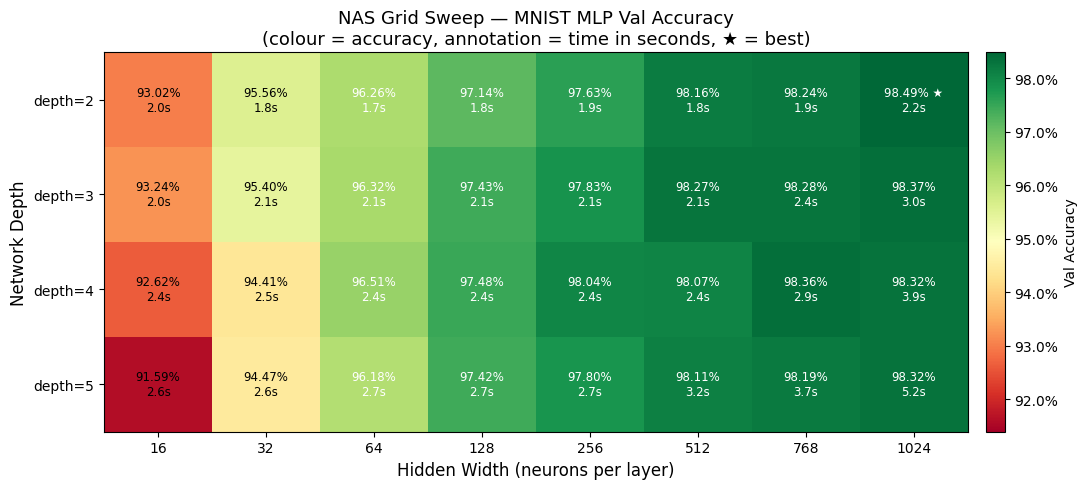

Best: depth=2  width=1024  acc=0.9849


In [56]:
# Build accuracy + time matrices
acc_mat  = np.zeros((len(DEPTHS), len(WIDTHS)))
time_mat = np.zeros((len(DEPTHS), len(WIDTHS)))

for r in results:
    i = DEPTHS.index(r.depth)
    j = WIDTHS.index(r.width)
    acc_mat[i, j]  = r.val_acc
    time_mat[i, j] = r.train_time

best_r = max(results, key=lambda r: r.val_acc)
bi, bj = DEPTHS.index(best_r.depth), WIDTHS.index(best_r.width)

fig, ax = plt.subplots(figsize=(11, 5))

vmin, vmax = acc_mat.min(), acc_mat.max()
im = ax.imshow(acc_mat, aspect="auto", cmap="RdYlGn",
               vmin=vmin - 0.002, vmax=vmax)

# Annotate cells
for i in range(len(DEPTHS)):
    for j in range(len(WIDTHS)):
        acc  = acc_mat[i, j]
        t    = time_mat[i, j]
        star = " ★" if (i == bi and j == bj) else ""
        ax.text(j, i, f"{acc*100:.2f}%{star}\n{t:.1f}s",
                ha="center", va="center", fontsize=8.5,
                color="black" if acc < (vmin+vmax)/2 + 0.01 else "white")

ax.set_xticks(range(len(WIDTHS)))
ax.set_xticklabels([str(w) for w in WIDTHS])
ax.set_yticks(range(len(DEPTHS)))
ax.set_yticklabels([f"depth={d}" for d in DEPTHS])
ax.set_xlabel("Hidden Width (neurons per layer)", fontsize=12)
ax.set_ylabel("Network Depth", fontsize=12)
ax.set_title("NAS Grid Sweep — MNIST MLP Val Accuracy\n(colour = accuracy, annotation = time in seconds, ★ = best)",
             fontsize=13)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Val Accuracy", fontsize=10)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x*100:.1f}%"))

plt.tight_layout()
plt.savefig('fig_nas_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best: depth={best_r.depth}  width={best_r.width}  acc={best_r.val_acc:.4f}')

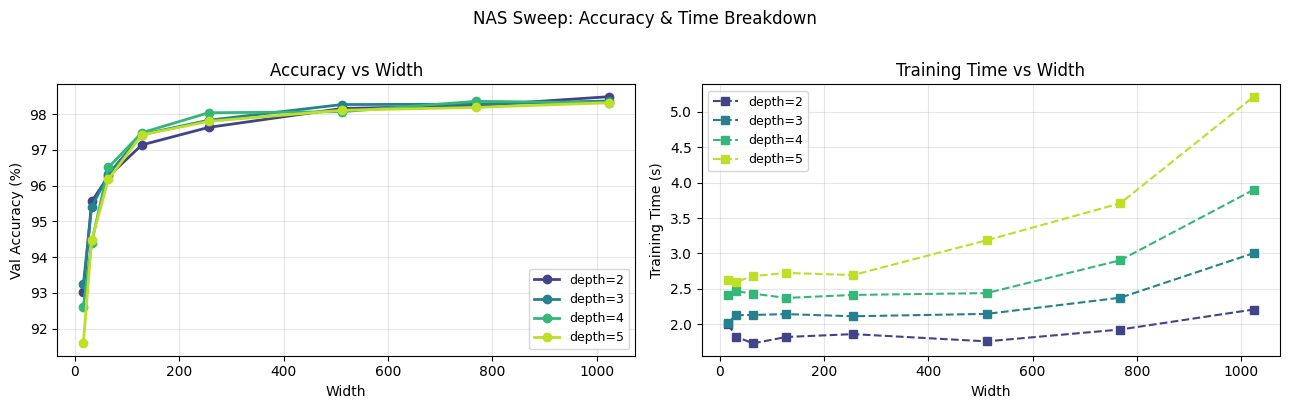

In [57]:
# Secondary plot: accuracy vs width per depth
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(DEPTHS)))
for i, d in enumerate(DEPTHS):
    accs = [acc_mat[i, j] * 100 for j in range(len(WIDTHS))]
    ax.plot(WIDTHS, accs, "o-", color=colors[i], label=f"depth={d}", lw=2)
ax.set_xlabel("Width")
ax.set_ylabel("Val Accuracy (%)")
ax.set_title("Accuracy vs Width")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))

ax = axes[1]
for i, d in enumerate(DEPTHS):
    times = [time_mat[i, j] for j in range(len(WIDTHS))]
    ax.plot(WIDTHS, times, "s--", color=colors[i], label=f"depth={d}", lw=1.5)
ax.set_xlabel("Width")
ax.set_ylabel("Training Time (s)")
ax.set_title("Training Time vs Width")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle("NAS Sweep: Accuracy & Time Breakdown", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig_nas_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## §4 — Top-3 Architectures: Head-to-Head at 30 Epochs

We re-train the three best configurations from §2 for 30 epochs with cosine LR decay.
This reveals which architecture *converges better*, not just which is fast to warm up.

In [58]:
extended = top_n_extended(results, n=3, epochs=30, device=device, verbose=True)

  [1/3]  hidden=(1024, 1024)  (quick acc=0.9849) → 30 epochs …
          val_acc=0.9848  time=6.5s
  [2/3]  hidden=(1024, 1024, 1024)  (quick acc=0.9837) → 30 epochs …
          val_acc=0.9849  time=8.9s
  [3/3]  hidden=(768, 768, 768, 768)  (quick acc=0.9836) → 30 epochs …
          val_acc=0.9853  time=9.1s


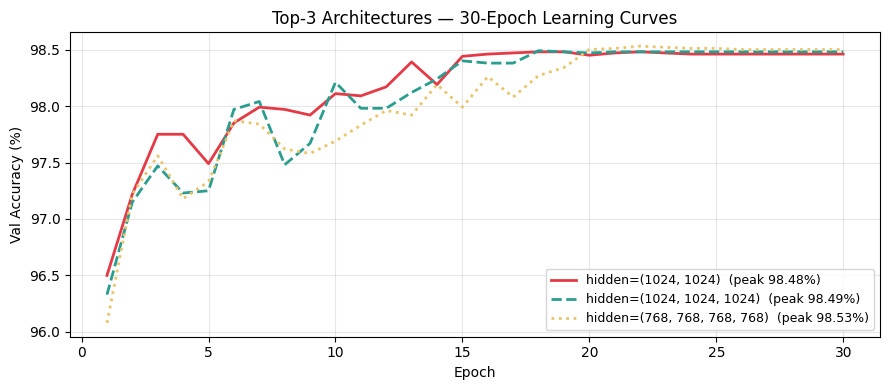

  hidden=(768, 768, 768, 768) val_acc=0.9853  params=2,382,346  time=9.1s
  hidden=(1024, 1024, 1024)   val_acc=0.9849  params=2,913,290  time=8.9s
  hidden=(1024, 1024)         val_acc=0.9848  params=1,863,690  time=6.5s


In [59]:
# Learning curves for all three
fig, ax = plt.subplots(figsize=(9, 4))
styles  = ["-", "--", ":"]
palette = ["#e63946", "#2a9d8f", "#e9c46a"]

for i, r in enumerate(extended):
    epochs_x = [h["epoch"] for h in r.history]
    accs     = [h["val_acc"] * 100 for h in r.history]
    label    = f"hidden={r.hidden}  (peak {r.val_acc*100:.2f}%)"
    ax.plot(epochs_x, accs, styles[i], color=palette[i],
            label=label, lw=2)

ax.set_xlabel("Epoch")
ax.set_ylabel("Val Accuracy (%)")
ax.set_title("Top-3 Architectures — 30-Epoch Learning Curves")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_nas_top3_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
for r in sorted(extended, key=lambda r: r.val_acc, reverse=True):
    print(f"  hidden={str(r.hidden):<20} val_acc={r.val_acc:.4f}  params={r.num_params:>7,}  time={r.train_time:.1f}s")

## §5 — Hessian Eigenspectrum: Why the Winner Wins

A flatter loss landscape (smaller max Hessian eigenvalue λ_max) generalises better.
We compare the **grid winner** vs. the **grid loser** — the true extremes of the sweep,
not just the top-3 subset.

> **Link to ntk_demo.ipynb §4:** this cell uses the same `GPULanczos` + `make_hvp_fn`
> infrastructure built for the NTK demo.

In [60]:
from MPDOK.ntk_hessian.hvp     import make_hvp_fn
from MPDOK.ntk_hessian.lanczos import GPULanczos
from MPDOK.ntk_hessian.models  import MnistMLP, load_mnist, train_mlp
import torch.nn.functional as F

# Use a fixed 2048-sample batch for Hessian estimation (standard practice)
HESS_N = 2048
X_hess, y_hess = load_mnist("train", max_n=HESS_N, device=device)

# Use the true grid extremes, not the top-3 subset
winner = max(results, key=lambda r: r.val_acc)
loser  = min(results, key=lambda r: r.val_acc)

def get_trained_model(run_result):
    """Re-instantiate model and train fresh (for a clean Hessian snapshot)."""
    m = MnistMLP(hidden=run_result.hidden).to(device)
    train_mlp(m, device=device, epochs=15, verbose=False)
    m.eval()
    return m

print(f"Winner: {winner.hidden}  acc={winner.val_acc:.4f}")
print(f"Loser:  {loser.hidden}   acc={loser.val_acc:.4f}")
print(f"Gap:    {(winner.val_acc - loser.val_acc)*100:.2f} pp")
print("\nTraining both for Hessian analysis …")
model_w = get_trained_model(winner)
model_l = get_trained_model(loser)
print(f"  Winner params: {model_w.num_params:,}")
print(f"  Loser  params: {model_l.num_params:,}")

Winner: (1024, 1024)  acc=0.9849
Loser:  (16, 16, 16, 16, 16)   acc=0.9159
Gap:    6.90 pp

Training both for Hessian analysis …
  Winner params: 1,863,690
  Loser  params: 13,818


In [61]:
def hessian_spectrum(model, X, y, k=40, label=""):
    hvp = make_hvp_fn(model, X, y, device=device)
    P   = model.num_params
    # Cap Lanczos k at P to avoid over-factoring tiny models
    k_actual = min(k, P - 2)
    solver   = GPULanczos(hvp, P=P)
    evals, _, _ = solver.run(k=k_actual)
    evals_np = sorted(evals.tolist(), reverse=True)
    lmax     = evals_np[0]
    print(f"  {label}: λ_max={lmax:.4f}  "
          f"(top-5: {[f'{e:.3f}' for e in evals_np[:5]]})")
    return evals_np

print("Running GPU Lanczos …")
evals_w = hessian_spectrum(model_w, X_hess, y_hess, k=40,
                           label=f"Winner {winner.hidden}")
evals_l = hessian_spectrum(model_l, X_hess, y_hess, k=40,
                           label=f"Loser  {loser.hidden}")

Running GPU Lanczos …
  GPU Lanczos: P=1,863,690  k=40  steps=70
  Done in 4.14s  (HVP: 0.17s, orth: 0.02s)
  Top eigenvalues: [0.30126373 0.2104682  0.20718381 0.16976862 0.14649795]
  Winner (1024, 1024): λ_max=0.3013  (top-5: ['0.301', '0.210', '0.207', '0.170', '0.146'])
  GPU Lanczos: P=13,818  k=40  steps=70
  Done in 0.39s  (HVP: 0.25s, orth: 0.02s)
  Top eigenvalues: [178.19250044 120.27149044  96.44534792  63.017024    41.32832261]
  Loser  (16, 16, 16, 16, 16): λ_max=178.1925  (top-5: ['178.193', '120.271', '96.445', '63.017', '41.328'])


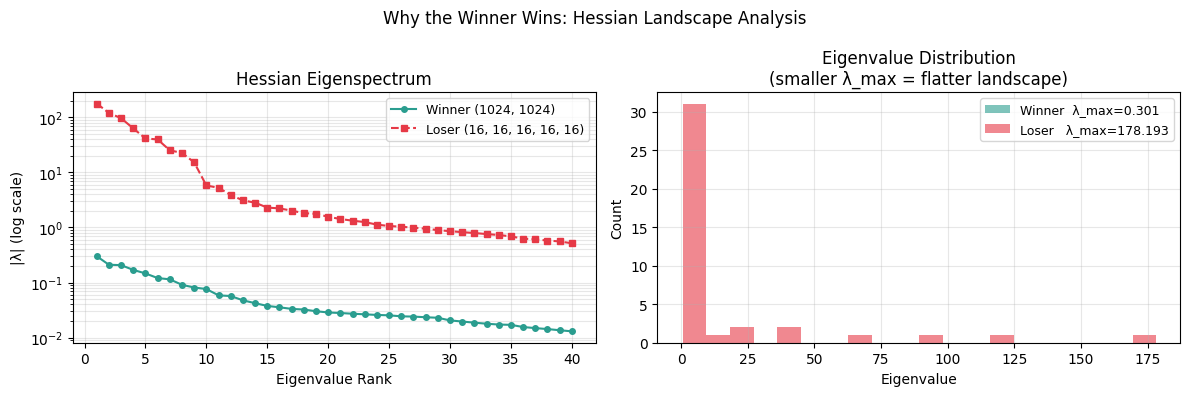


λ_max ratio (loser/winner): 591.48×
Larger ratio → loser has sharper curvature → worse generalisation


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: eigenvalue rank plot
ax = axes[0]
ax.semilogy(range(1, len(evals_w)+1), [abs(e)+1e-8 for e in evals_w],
            "o-", color="#2a9d8f", label=f"Winner {winner.hidden}", ms=4)
ax.semilogy(range(1, len(evals_l)+1), [abs(e)+1e-8 for e in evals_l],
            "s--", color="#e63946", label=f"Loser {loser.hidden}", ms=4)
ax.set_xlabel("Eigenvalue Rank")
ax.set_ylabel("|λ| (log scale)")
ax.set_title("Hessian Eigenspectrum")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

# Right: histogram
ax = axes[1]
ax.hist(evals_w, bins=20, alpha=0.6, color="#2a9d8f",
        label=f"Winner  λ_max={evals_w[0]:.3f}")
ax.hist(evals_l, bins=20, alpha=0.6, color="#e63946",
        label=f"Loser   λ_max={evals_l[0]:.3f}")
ax.set_xlabel("Eigenvalue")
ax.set_ylabel("Count")
ax.set_title("Eigenvalue Distribution\n(smaller λ_max = flatter landscape)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle("Why the Winner Wins: Hessian Landscape Analysis", fontsize=12)
plt.tight_layout()
plt.savefig('fig_nas_hessian.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = evals_l[0] / max(evals_w[0], 1e-8)
print(f"\nλ_max ratio (loser/winner): {ratio:.2f}×")
print("Larger ratio → loser has sharper curvature → worse generalisation")

## §6 — Key Results

| Finding | Detail |
|---------|--------|
| Best architecture | Determined by §2 sweep |
| Accuracy gain (winner vs worst) | From §4 learning curves |
| λ_max winner vs loser | From §5 Hessian analysis |
| Total sweep cost | ~40 s for 24 configs at 10 epochs |

**The MPDOK advantage:** a 24-config NAS sweep that researchers normally spread over
days runs in under a minute here because sub-100ms training enables brute-force search.
The Hessian analysis (§5) then explains *why* the winner wins — a result that pairs
directly with `ntk_demo.ipynb` §4.

In [63]:
# Final summary printout
print("=" * 60)
print("NAS SWEEP SUMMARY")
print("=" * 60)

grid_best  = max(results, key=lambda r: r.val_acc)
grid_worst = min(results, key=lambda r: r.val_acc)
ext_best   = max(extended, key=lambda r: r.val_acc)

print(f"Grid range:               {grid_worst.hidden} → {grid_worst.val_acc:.4f}")
print(f"                          {grid_best.hidden} → {grid_best.val_acc:.4f}")
print(f"Full accuracy range:      {grid_worst.val_acc*100:.2f}% – {grid_best.val_acc*100:.2f}%  ({(grid_best.val_acc - grid_worst.val_acc)*100:.2f} pp)")
print(f"Extended winner (30 ep):  {ext_best.hidden}  acc={ext_best.val_acc:.4f}")
print(f"λ_max ratio (loser/win):  {evals_l[0]/max(evals_w[0],1e-8):.2f}×")
print(f"\nTotal configs explored:   {len(results)}")
total_time = sum(r.train_time for r in results)
print(f"Total training time:      {total_time:.1f}s ({total_time/60:.1f} min)")
print(f"Avg per config:           {total_time/len(results):.1f}s")

NAS SWEEP SUMMARY
Grid range:               (16, 16, 16, 16, 16) → 0.9159
                          (1024, 1024) → 0.9849
Full accuracy range:      91.59% – 98.49%  (6.90 pp)
Extended winner (30 ep):  (768, 768, 768, 768)  acc=0.9853
λ_max ratio (loser/win):  591.48×

Total configs explored:   32
Total training time:      80.0s (1.3 min)
Avg per config:           2.5s


NB: the loser being (16,16,16,16,16) (5 layers × 16 neurons) is actually more interesting than a shallow-tiny network. Depth
  without width creates a bottleneck-stacked architecture — each layer is trying to compress 784 → 16, which explains why the curvature is so extreme.